In [1]:
!hostname

node093


In [2]:
import importlib
import IPython.display as ipd
import numpy as np
from src.binaural_attn_lightning import BinauralAttentionModule
from pathlib import Path
import os 
import yaml
import tqdm
import scipy.signal as signal 
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import sys 

sys.path.append("/om2/user/imgriff/datasets/spatial_audio_pipeline/utils/")
import util_audio

%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
config = yaml.load(open('/om2/user/imgriff/projects/Auditory-Attention/config/binaural_attn/dev_voice_and_loc_cue_001.yaml', 'r'), Loader=yaml.FullLoader)

In [4]:
batch_size = 1
## Make sure model can run on validation set 
config['num_workers'] = 0
config['hparas']['batch_size'] = batch_size


In [5]:
module = BinauralAttentionModule(config=config)


input_channels=2
num_classes={'num_words': 800}
Model performing word task


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [6]:
train_set = module.dataset(**config['corpus'], mode='train')

1068 files in train concat dataset


In [7]:
eg_ix = 30
sr = 50000
cue, fg, bg, word = train_set[eg_ix]

In [8]:
cue.shape

(2, 125000)

In [9]:
cue_frqs, cue_pxx = util_audio.power_spectrum(cue.mean(0), sr=sr)
fg_frqs, fg_pxx = util_audio.power_spectrum(fg.mean(0), sr=sr)
bg_frqs, bg_pxx = util_audio.power_spectrum(bg.mean(0), sr=sr)

In [11]:
# speech_ixs

In [12]:
print(np.sqrt(np.mean(np.power(cue_pxx[speech_ixs] - fg_pxx[speech_ixs],2))))
print(np.sqrt(np.mean(np.power(cue_pxx[speech_ixs] - cue_pxx[speech_ixs],2))))

NameError: name 'speech_ixs' is not defined

In [13]:
np.abs(cue_pxx[speech_ixs] - bg_pxx[speech_ixs]).mean()

NameError: name 'speech_ixs' is not defined

In [14]:
frq, ccf = signal.coherence(cue.mean(0), fg.mean(0), fs=sr, nperseg=512)
frq, ccb = signal.coherence(cue.mean(0), bg.mean(0), fs=sr, nperseg=512)

In [15]:
np.sqrt(np.mean(ccf**2)), np.sqrt(np.mean(ccb**2))

(0.007903973, 0.0030960736)

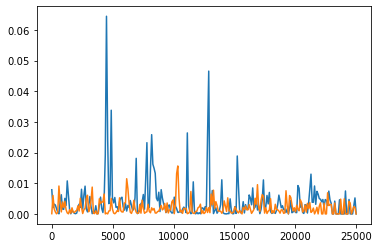

In [16]:
plt.plot(frq, ccf)
plt.plot(frq, ccb)

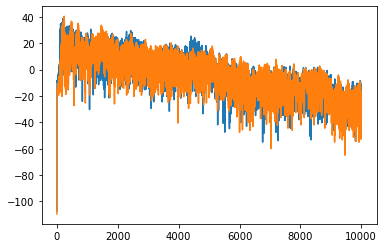

In [17]:
plt.plot(cue_frqs[:25000], cue_pxx[:25000])
plt.plot(cue_frqs[:25000], fg_pxx[:25000])
# plt.plot(bg_frqs[:25000], bg_pxx[:25000])

In [20]:
## COHERENCE DOESN"T TELL US MUCH

from ipywidgets import Output, GridspecLayout

sr = 50000

for eg_ix in range(10):
    cue, fg, bg, word = train_set[eg_ix]
    grid = GridspecLayout(1, 3, align_items='center')
    out = Output()
    with out:
        ipd.display(ipd.Audio(cue, rate=sr, normalize=False))
    grid[0,0] = out  
    out = Output()
    with out:
        ipd.display(ipd.Audio(fg, rate=sr, normalize=False))
    grid[0,1] = out
    out = Output()
    with out:
        ipd.display(ipd.Audio(bg, rate=sr, normalize=False))
    grid[0,2] = out

    ipd.display(grid)
    frq, ccf = signal.coherence(cue.mean(0), fg.mean(0), fs=sr, nperseg=512)
    frq, ccb = signal.coherence(cue.mean(0), bg.mean(0), fs=sr, nperseg=512)
    ixs = np.argwhere(frq < 8000)
    print(np.sqrt(np.mean(ccf[ixs]**2)), np.sqrt(np.mean(ccb[ixs]**2)))

GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

0.008749075 0.0047413367


GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

0.022007963 0.0017833553


GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

...

0.003331817 0.0027237828


GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

0.0043064817 0.004791672


GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

0.0013389561 0.0021106661


In [42]:
ipd.Audio(fg, rate=sr, normalize=False)


In [6]:
# class_map =  model.dataset(**config['corpus'], mode='val').class_map()

# ix_to_word = {v:k for k,v in class_map.items()}